In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [2]:
orders = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
customers = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
products = pd.read_csv('//kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
payments = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')
order_items = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')

In [3]:
delivered_orders = orders[orders['order_status'] == 'delivered']['order_id'].nunique()
total = orders['order_id'].nunique()
delivered_percent = delivered_orders/total * 100
print(f'Всего заказов: {total}')
print(f'Доставленных заказов: {delivered_orders}')
print(f'Процент доставленных заказов: {delivered_percent}')

Всего заказов: 99441
Доставленных заказов: 96478
Процент доставленных заказов: 97.02034372140264


In [4]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [5]:
# 1. Сначала превращаем колонку с текстом в формат даты (обязательный шаг)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# 2. Теперь правильно достаем год, месяц и день недели через специальный метод .dt
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()

# 3. Проверим, что новые колонки появились в таблице
display(orders.head(3))


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,year,month,day_of_week
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017,10,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018,7,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018,8,Wednesday


In [6]:
df = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(payments, on='order_id', how='left')
    .merge(order_items, on='order_id', how='left')
)

In [7]:
orders[~orders['order_id'].isin(order_items['order_id'])]['order_status'].value_counts()

order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64

In [8]:
order_items.groupby('order_id')['product_id'].count().describe()

count    98666.000000
mean         1.141731
std          0.538452
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         21.000000
Name: product_id, dtype: float64

****Большинство заказов состоят из одного товара, однако присутствуют заказы с большим количеством позиций (до 21), поэтому при объединении таблиц на уровне товаров необходимо учитывать изменение гранулярности данных, чтобы избежать двойного подсчёта метрик.****

In [9]:
payments.groupby('order_id').size().describe()

count    99440.000000
mean         1.044710
std          0.381166
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         29.000000
dtype: float64

показатель mean 1.04 показывает что по одному ордеру у нас в среднем 1 запись 

In [10]:
number_of_products_per_order = (order_items.groupby('order_id')['product_id']
    .count()
    .gt(1)
    .sum()
)
multi_orders = (
    order_items.groupby('order_id')['product_id']
    .count()
    .gt(1)
    .sum()
)

percent = multi_orders / order_items['order_id'].nunique() * 100
print(percent)
print(number_of_products_per_order)

9.93554010500071
9803


****столько раз у нас больше одного товара за одну покупку 
9.93554010500071 и столько в процентах таких заказов
****

In [11]:
product_revenue = order_items['price'].sum()
gmv = payments['payment_value'].sum()
print(product_revenue)
print(gmv)

13591643.7
16008872.120000001


**** Общий оборот платформы составил 16008872.120000001, из которых 13591643.7 приходится на стоимость товаров без учёта доставки.****

In [12]:
order_base = orders.merge(customers, on='customer_id', how='left')


order_items_agg = order_items.groupby('order_id', as_index=False).agg({
    'price': 'sum',
    'freight_value': 'sum',
    
})


payments_agg = payments.groupby('order_id', as_index=False).agg({
    'payment_value': 'sum',
    'payment_installments': 'max',})

In [13]:
df_final = (
    order_base
    .merge(order_items_agg, on='order_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
)



In [14]:
df_final['payment_value'].sum()
df_final['order_id'].nunique()
df_final['payment_value'].mean()

np.float64(160.9902666934835)

In [15]:
#mean по товарам в заказе
order_items.groupby('order_id')['product_id'].count().mean()

np.float64(1.1417306873695092)

In [16]:
df_final['order_purchase_timestamp'] = pd.to_datetime(df_final['order_purchase_timestamp'])

df_final['year_month'] = df_final['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = df_final.groupby('year_month')['payment_value'].sum()

In [17]:
df_final.groupby('customer_unique_id')['payment_value'].sum().sort_values(ascending=False).head(10)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    13664.08
46450c74a0d8c5ca9395da1daac6c120     9553.02
da122df9eeddfedc1dc1f5349a1a690c     7571.63
763c8b1c9c68a0229c42c9fc6f662b93     7274.88
dc4802a71eae9be1dd28f5d788ceb526     6929.31
459bef486812aa25204be022145caa62     6922.21
ff4159b92c40ebe40454e3e6a7c35ed6     6726.66
4007669dec559734d6f53e029e360987     6081.54
5d0a2980b292d049061542014e8960bf     4809.44
eebb5dda148d3893cdaf5b5ca3040ccb     4764.34
Name: payment_value, dtype: float64

In [18]:
df_final.groupby('customer_state')['payment_value'].sum().sort_values(ascending=False)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
SC     623086.43
BA     616645.82
DF     355141.08
GO     350092.31
ES     325967.55
PE     324850.44
CE     279464.03
PA     218295.85
MT     187029.29
MA     152523.02
PB     141545.72
MS     137534.84
PI     108523.97
RN     102718.13
AL      96962.06
SE      75246.25
TO      61485.33
RO      60866.20
AM      27966.93
AC      19680.62
AP      16262.80
RR      10064.62
Name: payment_value, dtype: float64

In [19]:
repeat = (
    df_final.groupby('customer_unique_id')['order_id']
    .nunique()
    .gt(1)
    .mean()
    * 100
)

print(f'{repeat:.2f}%')

3.12%


**процент возвращающихся клиентов**

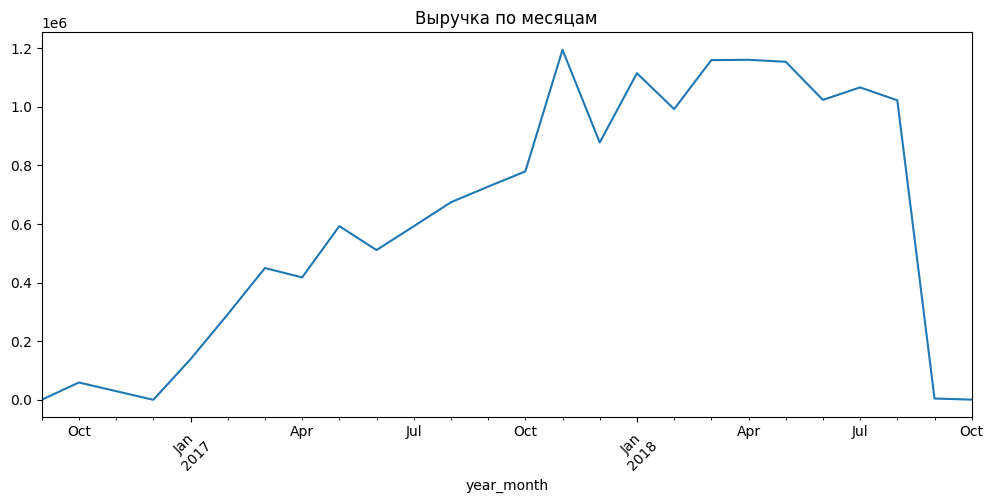

In [20]:
import matplotlib.pyplot as plt
monthly_revenue.plot(
    x='year_month',
    y='revenue',
    figsize=(12, 5),
    title='Выручка по месяцам'
)
plt.xticks(rotation=45)
plt.show()

In [21]:
#количество заказов
total_orders = df_final['order_id'].nunique()

#уникальные покупатели
unique_customers = df_final['customer_unique_id'].nunique()

#оборот
gmv = df_final['payment_value'].sum()

#средний чек
aov = df_final['payment_value'].mean()

#среднее количество заказов на клиента
orders_per_customer = (
    df_final['order_id'].nunique()
    / df_final['customer_unique_id'].nunique()
)

In [22]:
df_final[
    [
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]
].dtypes


order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [23]:
df_final['order_delivered_customer_date'] = pd.to_datetime(
    df_final['order_delivered_customer_date'],
    errors='coerce'
)

In [24]:
df_final['delivery_days'] = (df_final['order_delivered_customer_date']
                             - df_final['order_purchase_timestamp']).dt.days

In [25]:
df_final['delivery_days'].mean()

np.float64(12.094085575687217)

In [26]:
repeat

np.float64(3.1187562437562435)

In [27]:
late_delivery = (
    (
        df_final['order_delivered_customer_date']
        >
        df_final['order_estimated_delivery_date']
    )
    .mean()
    * 100
)

In [28]:
late_delivery

np.float64(7.870998883760219)

In [29]:
top_states = (
    df_final
    .groupby('customer_state')['payment_value']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print(top_states)

customer_state
SP    5998226.96
RJ    2144379.69
MG    1872257.26
RS     890898.54
PR     811156.38
Name: payment_value, dtype: float64


In [30]:
top_cities = (
    df_final
    .groupby('customer_city')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)
print(top_cities)

customer_city
sao paulo         15540
rio de janeiro     6882
belo horizonte     2773
brasilia           2131
curitiba           1521
Name: order_id, dtype: int64


In [31]:
items_products = (
    order_items
    .merge(products, on='product_id', how='left')
)

In [32]:
top_categories = (
    items_products
    .groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_categories)

product_category_name
beleza_saude              1258681.34
relogios_presentes        1205005.68
cama_mesa_banho           1036988.68
esporte_lazer              988048.97
informatica_acessorios     911954.32
moveis_decoracao           729762.49
cool_stuff                 635290.85
utilidades_domesticas      632248.66
automotivo                 592720.11
ferramentas_jardim         485256.46
Name: price, dtype: float64
